# Creating an xG model from scratch 
### by Declan Tuohy
---

##### This notebook builds a simple xG model from Statsbomb Open Data using logistic regression. I start with geometric shot features (shot angle, goal distance), before adding contextual features in my final model. I compare my final and baseline models against Statsbomb's official xG model.
---

## Imports, Setting up and cleaning data

In [1]:
import statsbombpy
from statsbombpy import sb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings("ignore", category=NoAuthWarning) # Ignore warnings about missing authentication, as we can still access public data without it

In [2]:
# Get matches for La Liga for the 2018/19, 2019/20 and 2020/21 seasons

matches_1 = sb.matches(competition_id=11,season_id=90) # 2020/21 season
matches_2 = sb.matches(competition_id=11,season_id=42) # 2019/20 season
matches_3 = sb.matches(competition_id=11,season_id=4) # 2018/19 season
matches = pd.concat([matches_1, matches_2, matches_3], ignore_index=True)

### Creating Datafile with all shots

In [3]:
all_shots = []

for match_id in matches["match_id"]:
    events = sb.events(match_id=match_id)
    
    shots = events[events["type"] == "Shot"].copy()
    shots["match_id"] = match_id
    
    all_shots.append(shots)

shots_df = pd.concat(all_shots, ignore_index=True)

# merge season and match_id from matches to shots_df to identify which match for each shot
matches_id = matches[["season","match_id"]]
matches_id = matches_id.drop_duplicates()

shots_df = pd.merge(shots_df,matches_id,on="match_id", how="left")

In [4]:
shot_events = shots_df[
    [
        "season",
        "match_id",
        "team",
        "team_id",
        "player",
        "player_id",
        "minute",
        "second",
        "location",
        "shot_outcome",
        "shot_body_part",
        "shot_technique",
        "shot_type",
        "shot_one_on_one",
        "shot_aerial_won",
        "shot_key_pass_id",
        'shot_open_goal',
        'shot_first_time',
        'goalkeeper_position',
        "play_pattern",
        "shot_statsbomb_xg"
    ]
]

shot_events = shot_events.dropna(subset=["location", "shot_outcome"])

---
## Creating Shot Angle and Shot Distance Variables

### Shot Angle

centre of the goal: (120,40)

left post: (120,36)

right post: (120,44)

we find the shooting angle using basic geometry, note that shots are standardised for both teams, they both shoot at the goal positioned at `x = 120`

In [5]:
# split location into x and y coordinates
shot_events[["x_location","y_location"]] = pd.DataFrame(
    shot_events["location"].tolist()
)

shot_events = pd.DataFrame(shot_events)

In [6]:
goal_x = 120
left_post_y = 36
right_post_y = 44

x = shot_events["x_location"]
y = shot_events["y_location"]

v1_x = goal_x - x
v1_y = left_post_y - y

v2_x = goal_x - x
v2_y = right_post_y - y

dot = v1_x * v2_x + v1_y * v2_y
mag1 = np.sqrt(v1_x**2 + v1_y**2)
mag2 = np.sqrt(v2_x**2 + v2_y**2)

cos_theta = dot / (mag1 * mag2)
cos_theta = np.clip(cos_theta, -1, 1) # Clip values to avoid numerical issues with arccos
shot_angle = np.arccos(cos_theta)

shot_events["shot_angle_rad"] = shot_angle

### Goal distance

In [7]:
goal_x = 120
goal_centre_y = 40

mag_x = (goal_x - shot_events['x_location']) 
mag_y = (goal_centre_y - shot_events['y_location'])

goal_distance = np.sqrt(mag_x**2 + mag_y**2) # distance formula
shot_events['goal_distance'] = goal_distance

---
## Creating a Basic Model: Only Shot Angle and Goal Distance

In [8]:
shot_events['is_goal'] = (
    shot_events['shot_outcome'] == "Goal"
).astype(int)

In [9]:
# Check overall correlation between features and target variable, as well as basic statistics and missing values
print(shot_events[["goal_distance", "shot_angle_rad", "is_goal"]].corr())
print(shot_events.shape)
print(shot_events["is_goal"].mean())
print(shot_events[["goal_distance", "shot_angle_rad"]].describe())

                goal_distance  shot_angle_rad   is_goal
goal_distance        1.000000       -0.700962 -0.224202
shot_angle_rad      -0.700962        1.000000  0.275736
is_goal             -0.224202        0.275736  1.000000
(2478, 26)
0.12994350282485875
       goal_distance  shot_angle_rad
count    2478.000000     2478.000000
mean       18.398320        0.440577
std         8.116008        0.262718
min         1.431782        0.045627
25%        12.128169        0.277148
50%        17.814740        0.359687
75%        23.935016        0.519047
max        80.202805        2.622447


### Simple Regression Model with SKLearn

We use a simple train/test split and `GroupShuffleSplit` to make sure training and testing are independent, one important thing to note is that we group the data by matches (instead of just random shots) to prevent bias occuring from specific match flows or tactics

In [10]:
model_df = shot_events[["match_id", "goal_distance", "shot_angle_rad", "is_goal"]].copy()
model_df = model_df.dropna()

from sklearn.model_selection import GroupShuffleSplit

# simple train/test split
X = model_df[["goal_distance", "shot_angle_rad"]]
y = model_df["is_goal"]
groups = model_df["match_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups)) # we split into groups of matches to make sure training and testing are independent

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train goal rate:", y_train.mean(), "Test goal rate:", y_test.mean())

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

xg_test = clf.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": clf.coef_[0]
})


Train size: (1985, 2) Test size: (493, 2)
Train goal rate: 0.13350125944584382 Test goal rate: 0.11561866125760649


,feature,coefficient
0,goal_distance,-0.073156
1,shot_angle_rad,1.090504


---
## Adding Contextual Variables to Improve my xG Model

After adding the key geometric variables, I then added a number of contextual variables to improve the accuracy of the model, these variables consisted of:

- Shot type (open play, penalty, free kick)
- Shot body part (head, L foot, R foot)
- Is the shot 1-on-1? 
- Is the shot into an open goal?
- Is the shot first time?

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# For the model, we will use the following features:
model_df = shot_events[["match_id", 
                        "goal_distance", 
                        "shot_angle_rad",
                        "shot_type", 
                        "shot_body_part",
                        'shot_one_on_one', 
                        'shot_open_goal',
                        'shot_first_time', 
                        'shot_statsbomb_xg', # for ease in future analysis, we won't use this in the model
                        "is_goal"]].copy()

# Handle missing values separately by column type
# For boolean columns: fill NaNs with False and convert to int (0/1)
bool_cols = ['shot_one_on_one', 'shot_open_goal', 'shot_first_time']
for col in bool_cols:
    model_df[col] = model_df[col].fillna(False).astype(int)

# For categorical string columns: fill NaNs with a placeholder
categorical_cols = ["shot_type", "shot_body_part"]
model_df[categorical_cols] = model_df[categorical_cols].fillna('Unknown')

# Numeric columns (goal_distance, shot_angle_rad) should already have no NaNs from earlier processing

# Drop rows with any remaining missing values (keeps things simple for baseline)
model_df = model_df.dropna()

model_df.head()

X = model_df[[  "goal_distance", 
                "shot_angle_rad",
                "shot_type", 
                "shot_body_part",
                'shot_one_on_one', 
                'shot_open_goal',
                'shot_first_time'
                        ]]
y = model_df["is_goal"]
groups = model_df["match_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups)) # we split into groups of matches to make sure training and testing are independent

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

numeric_features = ["goal_distance", "shot_angle_rad"]

categorical_features = ["shot_type", 
                        "shot_body_part",
                        'shot_one_on_one', 
                        'shot_open_goal',
                        'shot_first_time'
                        ]

# We will use a ColumnTransformer to apply different preprocessing to numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# We can then create a pipeline that first applies the preprocessor and then fits a logistic regression model
xg_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000))
])

xg_model.fit(X_train, y_train)

xg_test = xg_model.predict_proba(X_test)[:,1]

---
## Final Comparisons: How Strong is my model ?

### Creating an Analysis Function for the Most Important Metrics

In [12]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

# We can evaluate the model using log loss, Brier score and ROC AUC
def evaluate_probs(y_true, probs, name):
    return {
        "model": name,
        "log_loss": log_loss(y_true, probs),
        "brier": brier_score_loss(y_true, probs),
        "roc_auc": roc_auc_score(y_true, probs)
    }

### Full Model

In [13]:
full_test_probs = xg_model.predict_proba(X_test)[:, 1]
results = []
results.append(evaluate_probs(y_test, full_test_probs, "My full model"))

### Baseline Model

In [14]:
from sklearn.linear_model import LogisticRegression

X_base = model_df[["goal_distance", "shot_angle_rad"]]
y = model_df["is_goal"]
groups = model_df["match_id"]

X_base = model_df[["goal_distance", "shot_angle_rad"]]

Xb_train, Xb_test = X_base.iloc[train_idx], X_base.iloc[test_idx]
yb_train, yb_test = y.iloc[train_idx], y.iloc[test_idx]

baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(Xb_train, yb_train)
baseline_probs = baseline_model.predict_proba(Xb_test)[:, 1]

results.append(evaluate_probs(yb_test, baseline_probs, "Baseline model"))


### Statsbomb Official Model

In [15]:
statsbomb_test_probs = model_df.iloc[test_idx]["shot_statsbomb_xg"]
results.append(evaluate_probs(y_test, statsbomb_test_probs, "StatsBomb xG"))

In [16]:
results_df = pd.DataFrame(results)
results_df

,model,log_loss,brier,roc_auc
0,My full model,0.307521,0.088185,0.757404
1,Baseline model,0.338584,0.097843,0.681696
2,StatsBomb xG,0.298990,0.085983,0.774867


Log Loss: Lower is better

Brier Score: Lower is better

ROC AUC: Higher is better

The full model outperforms the baseline model on all three metrics, indicating that contextual features improve predictive performance beyond distance and angle alone. StatsBomb xG remains the strongest benchmark, but the final model performs relatively closely given its simpler structure.

---

## Visual Analysis

In [17]:
plot_df = model_df.copy()

plot_df["xg_model"] = xg_model.predict_proba(
    plot_df[
        [
            "goal_distance",
            "shot_angle_rad",
            "shot_type",
            "shot_body_part",
            "shot_one_on_one",
            "shot_open_goal",
            "shot_first_time"
        ]
    ]
)[:, 1]

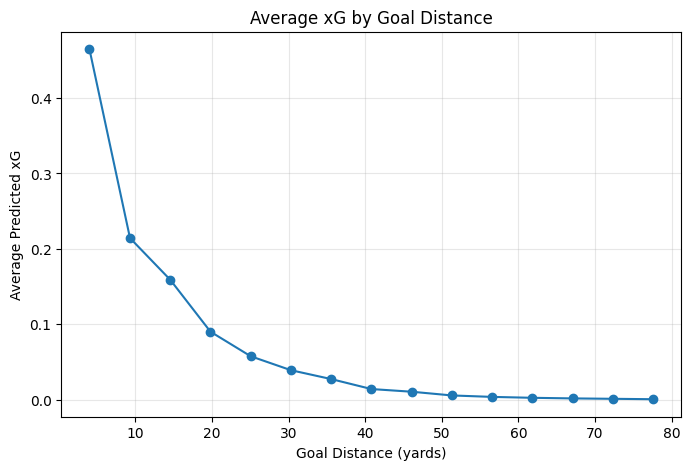

In [18]:
plot_df["distance_bin"] = pd.cut(plot_df["goal_distance"], bins=15)
distance_plot = (
    plot_df.groupby("distance_bin", observed=False)["xg_model"]
    .mean()
    .reset_index()
)

distance_plot["bin_mid"] = distance_plot["distance_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8, 5))
plt.plot(distance_plot["bin_mid"], distance_plot["xg_model"], marker="o")
plt.xlabel("Goal Distance (yards)") # only approximately yards
plt.ylabel("Average Predicted xG")
plt.title("Average xG by Goal Distance")
plt.grid(alpha=0.3)
plt.show()


This plot shows that predicted xG decreases as shots are taken from further away, which is consistent with football intuition. The steep drop at shorter distances suggests that proximity to goal is one of the strongest drivers of shot quality.

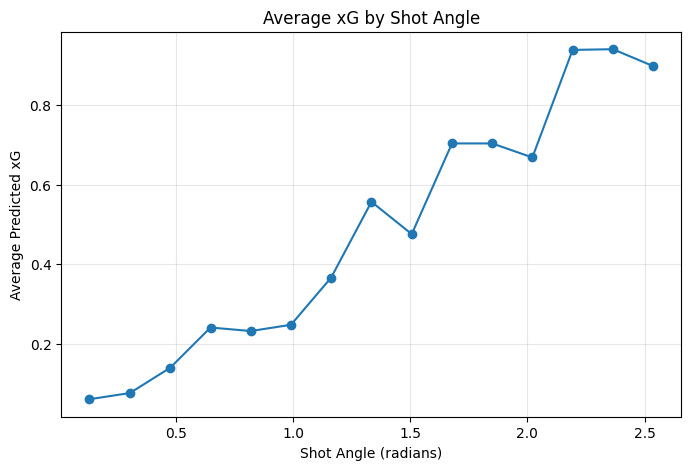

In [19]:
plot_df["angle_bin"] = pd.cut(plot_df["shot_angle_rad"], bins=15)
angle_plot = (
    plot_df.groupby("angle_bin", observed=False)["xg_model"]
    .mean()
    .reset_index()
)

angle_plot["bin_mid"] = angle_plot["angle_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8, 5))
plt.plot(angle_plot["bin_mid"], angle_plot["xg_model"], marker="o")
plt.xlabel("Shot Angle (radians)")
plt.ylabel("Average Predicted xG")
plt.title("Average xG by Shot Angle")
plt.grid(alpha=0.3)
plt.show()


This plot shows that xG generally increases as the shooting angle opens up. Central shots with a wider view of the goal are therefore assigned higher probabilities than shots taken from narrow angles

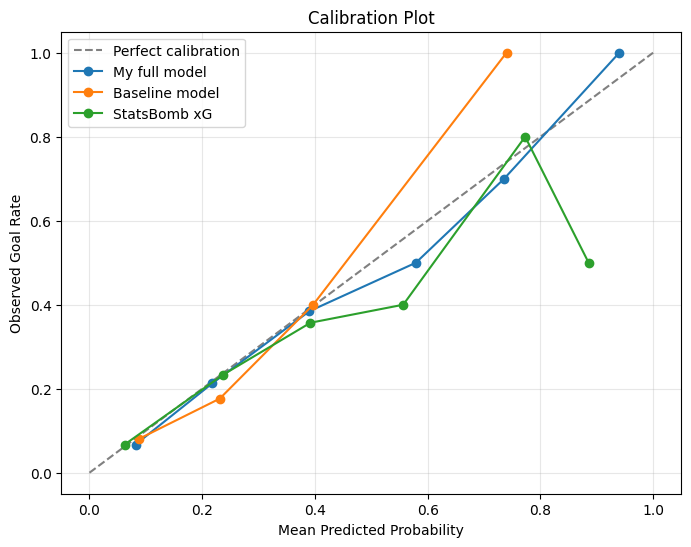

In [20]:
from sklearn.calibration import calibration_curve

# Calculate calibration curves
frac_pos_full, mean_pred_full = calibration_curve(y_test, full_test_probs, n_bins=6)
frac_pos_base, mean_pred_base = calibration_curve(y_test, baseline_probs, n_bins=6)
frac_pos_sb, mean_pred_sb = calibration_curve(y_test, statsbomb_test_probs, n_bins=6)

plt.figure(figsize=(8, 6))

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

# Model curves
plt.plot(mean_pred_full, frac_pos_full, marker="o", label="My full model")
plt.plot(mean_pred_base, frac_pos_base, marker="o", label="Baseline model")
plt.plot(mean_pred_sb, frac_pos_sb, marker="o", label="StatsBomb xG")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Goal Rate")
plt.title("Calibration Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The calibration plot compares predicted xG with the observed goal rate across probability bins. A model close to the diagonal is well calibrated, meaning its predicted probabilities are broadly aligned with real outcomes

---


## Summary & Conclusions
This project built an expected goals model from StatsBomb Open Data using logistic regression. I began with a simple baseline model based only on shot angle and goal distance, then extended it by adding contextual features such as shot type, body part, one-on-one situations, open-goal opportunities, and first-time finishes.

The final model outperformed the baseline model across all three evaluation metrics: log loss, Brier score, and ROC AUC. This indicates that while shot geometry captures much of the core signal in shot quality, additional contextual features provide meaningful extra predictive value. The visualisations of goal distance and shot angle also showed that the model behaves in a way that is consistent with football intuition, assigning higher xG values to closer and more central shooting situations.

StatsBomb’s official xG model remained the strongest benchmark overall, which is expected given that it is a professionally developed model and likely benefits from richer feature engineering and broader modelling choices. However, the gap between my final model and StatsBomb xG was relatively small, showing that a simple and interpretable model trained on open event data can still recover a large share of the predictive signal.

A key limitation of this project is that it uses event data only, rather than tracking data. This means the model cannot directly account for defender positioning, goalkeeper positioning, or other spatial features that are often important in real-world xG models. In addition, the model was trained only on La Liga matches, so its performance may not transfer perfectly to other leagues or competitions.

Overall, the project shows that a clean, reproducible xG model can be built using open data and relatively simple methods. While it does not attempt to match state-of-the-art commercial models, it demonstrates a credible modelling pipeline, sensible feature engineering, and meaningful evaluation against both a simple baseline and an industry benchmark.